In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [11]:
group_sfr = np.where(np.isinf(np.log10(halos["GroupSFR"])), -4, np.log10(halos["GroupSFR"]))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [13]:
h = 0.6774

In [14]:
m200c = np.log10((10**np.array(f["M200c"]))*h)
c200c = f["c200c"]

In [15]:
Mbh = np.log10(halos["GroupBHMass"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [40]:
mask_data = (mvir > 11.6) & (mvir < 11.7)& (np.array(c200c) > 0)

SFR-black hole mass correlation

In [41]:
mask_low_bh = Mbh[mask_data] < 8.1
mask_high_bh = Mbh[mask_data] > 8.1

Text(0, 0.5, 'PDF')

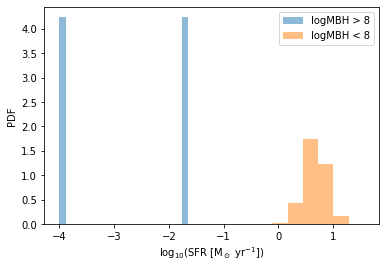

In [42]:
plt.hist(group_sfr[mask_data][mask_high_bh], density=True, label="logMBH > 8", bins=20, alpha=0.5)
plt.hist(group_sfr[mask_data][mask_low_bh], density=True, label="logMBH < 8", bins=20, alpha =0.5)
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("PDF")

Text(0, 0.5, 'PDF')

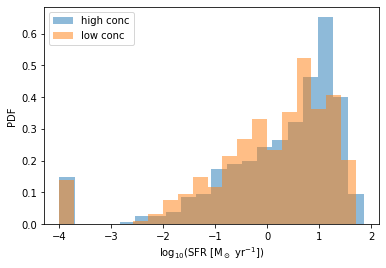

In [33]:
plt.hist(group_sfr[mask_data][mask_high_conc & mask_high_bh], density=True, label="high conc", bins=20, alpha=0.5)
plt.hist(group_sfr[mask_data][mask_low_conc & mask_high_bh], density=True, label="low conc", bins=20, alpha =0.5)
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("PDF")

SFR-conc correlation

In [26]:
median_conc = np.median(c200c[mask_data])
print(median_conc)
mask_high_conc = c200c[mask_data] > median_conc
mask_low_conc = c200c[mask_data] < median_conc

7.732859598031768


In [493]:
new_group_sfr = np.where(np.isinf(group_sfr[mask_data][mask_low]), -4,group_sfr[mask_data][mask_low])

ValueError: supplied range of [-inf, 2.2637248039245605] is not finite

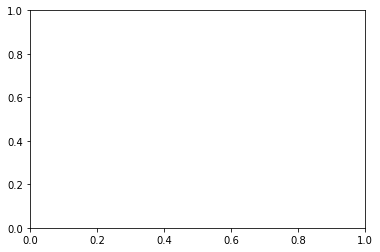

In [490]:
plt.hist(group_sfr[mask_data][mask_high_conc], density=True, label="high conc", bins=20, alpha=0.5)
plt.hist(group_sfr[mask_data][mask_low_conc], density=True, label="low conc", bins=20, alpha =0.5)
plt.legend()
plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel("PDF")